<a href="https://colab.research.google.com/github/talhahk24/ML_Predicting_Employee_Attrition/blob/main/ISOM_3360_Project_Coding_File_Group_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

### Dear Professor,


### We are pleased to present the coding portion of the 3360 Group Project for Group-5, consisting of:


### **Li Weitao, Wade (20802600)**


### **Li Kexin, Crystal (20731289)**


### **KHAN, Talha Hameed (20850023)**

### In our coding session, we have diligently ensured that all code cells are executable from top to bottom.

### However, please note that due to different evaluation techniques employed by various group members, some

### cells (Random Search) might take longer to run. We kindly ask for your patience during the execution

### of these cells. Alternatively, you may directly view our runned result embodied also in this ipynb file.

### The code is organized in the same order as our report, encompassing data preparation, modeling, and evaluation.

### In the evaluation section, we provide metrics such as AUC, Precision, Recall, and Accuracy for your convenience.

### For a more in-depth analysis and discussion on the importance of these metrics, please refer to the corresponding

### sections in our written report.

### You may also visit: https://www.kaggle.com/code/stanley0010/isom3360project?scriptVersionId=128548452 for our Kaggle's project display.


### Thank you for your attention, and we look forward to your feedback.

# **Data Import and Preparation**

In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Used for data operation
import pandas as pd
import numpy as np
from numpy import array

# Used for visualization
import matplotlib.pyplot as plt
from plotnine import *
import plotnine
import seaborn as sns

# Used for pre-processing
from sklearn import preprocessing
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# Used for model training and evaluation
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, GridSearchCV
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score


# Used for models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.datasets import load_iris

In [ ]:
Employees = pd.read_csv("../input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
Employees.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
Employees.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# **Preprocessing**

## **Preprocessing - Data Conversion**

In [ ]:
Employees = Employees.drop(["EmployeeCount", "EmployeeNumber"], axis = 1)
Attrition = pd.get_dummies(Employees["Attrition"])
Employees["Attrition"] = Attrition.drop("No", axis = 1)

In [ ]:
Employees.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# 'Gender', 'OverTime', 'MaritalStatus' and 'Department' are categorical variables, need processing
Employees = pd.get_dummies(
    Employees, columns=['Gender', 'OverTime', 'MaritalStatus', 'Department', 'EducationField','JobRole','Over18'], drop_first=True)
Employees['BusinessTravel'] = Employees['BusinessTravel'].map(
    {'Non-Travel': 1, 'Travel_Rarely': 2, 'Travel_Frequently': 3})

In [ ]:
Employees.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,41,1,2,1102,1,2,2,94,3,2,...,0,0,0,0,0,0,0,0,1,0
1,49,0,3,279,8,1,3,61,2,2,...,0,0,0,0,0,0,0,1,0,0
2,37,1,2,1373,2,2,4,92,2,1,...,1,0,0,1,0,0,0,0,0,0
3,33,0,3,1392,3,4,4,56,3,1,...,0,0,0,0,0,0,0,1,0,0
4,27,0,2,591,2,1,1,40,3,1,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
# Create a function to check if a value is of the string type
def is_string(value):
    return isinstance(value, str)

# Iterate through each element in the Employees DataFrame
for column in Employees.columns:
    for index, value in Employees[column].iteritems():
        if is_string(value):
            print(f"String value found at column '{column}', index {index}: {value}")

print("No sentence above me? It seems that we are clear with strings!")

No sentence above me? It seems that we are clear with strings!


## **Preprocessing - Features Selection**

It is noteworthy that we do a data split now to avoid using the test set's value for correlation generation (Overfit)

In [ ]:
# We will perform normalization on the "Employees" dataframe with our feature selection result and split the train and test set again

X = Employees.drop("Attrition", axis = 1)
y = Employees["Attrition"]

# split into train and test that need to be rebalanced later
X_train_old, X_test, y_train_old, y_test = train_test_split(
    X, y, test_size=0.4, random_state=3360)

split_df = pd.concat([X_train_old, y_train_old], axis=1)

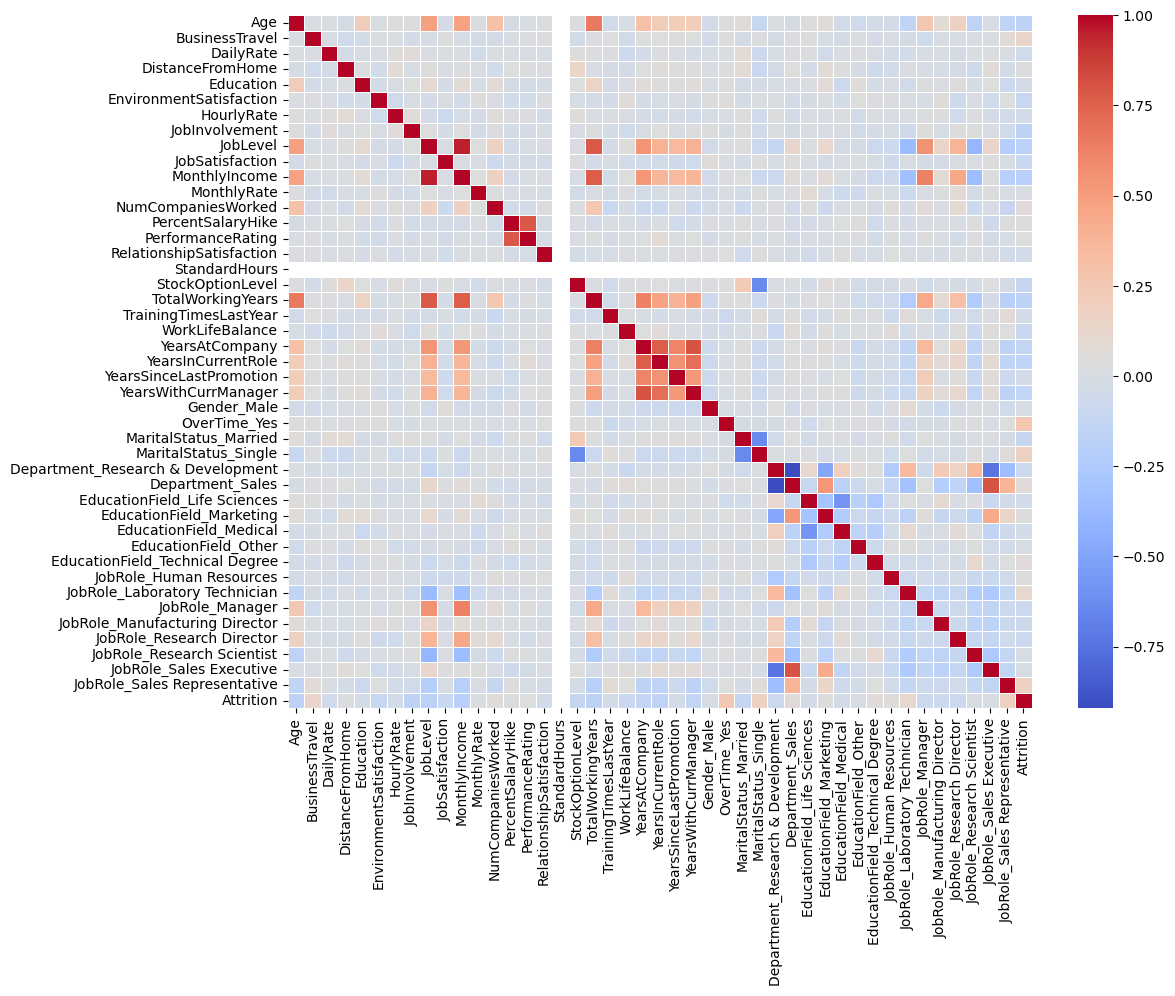

In [ ]:
# Compute the correlation matrix
correlation_matrix = split_df.corr()

# Create a heatmap using seaborn
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.show()

In [ ]:
# Sort the correlations with Attrition_Yes in ascending order
sorted_correlations = correlation_matrix['Attrition'].sort_values(ascending=True)

# Select the first 15 columns with the lowest correlations
lowest_corr_columns = sorted_correlations.head(15)

# Drop the 15 columns from the Employees DataFrame
Employees.drop(lowest_corr_columns.index, axis=1, inplace=True)

In [ ]:
# Print the 15 columns with their correlation values
print("15 columns with the lowest correlation with 'Attrition_Yes':")
print(lowest_corr_columns)

# We don't need to drop Within Features Correlated Columns anymore since they happen to be included in those with low correlation with the target variables

15 columns with the lowest correlation with 'Attrition_Yes':
MonthlyIncome               -0.186474
JobLevel                    -0.185057
TotalWorkingYears           -0.169230
Age                         -0.163910
JobInvolvement              -0.163044
YearsInCurrentRole          -0.157233
YearsWithCurrManager        -0.134955
YearsAtCompany              -0.126280
MaritalStatus_Married       -0.116596
StockOptionLevel            -0.113300
EnvironmentSatisfaction     -0.104542
JobSatisfaction             -0.100672
WorkLifeBalance             -0.097209
JobRole_Manager             -0.084251
JobRole_Research Director   -0.083466
Name: Attrition, dtype: float64


## **Preprocessing - Normalization**

In [ ]:
# In our normalization process, we only do "conservative" normalization...
# that is, on columns that are "materially large."
# We also perform only /100 rather than regular normalization process for "PercentSalaryHike" as it is already in percentage form

# Create a StandardScaler instance
scaler = StandardScaler()

# Perform z-score normalization on DailyRate and MonthlyRate columns
Employees[['DailyRate', 'MonthlyRate','HourlyRate']] = scaler.fit_transform(Employees[['DailyRate', 'MonthlyRate', 'HourlyRate']])

# Perform personalized normalization on PercentSalaryHike
Employees["PercentSalaryHike"] = Employees["PercentSalaryHike"]/100

In [ ]:
Employees

,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,HourlyRate,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,...,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manufacturing Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,1,2,0.742527,1,2,1.383138,0.726020,8,0.11,3,...,0,0,0,0,0,0,0,0,1,0
1,0,3,-1.297775,8,1,-0.240677,1.488876,1,0.23,4,...,0,0,0,0,0,0,0,1,0,0
2,1,2,1.414363,2,2,1.284725,-1.674841,6,0.15,3,...,0,0,1,0,0,1,0,0,0,0
3,0,3,1.461466,3,4,-0.486709,1.243211,1,0.11,3,...,0,0,0,0,0,0,0,1,0,0
4,0,2,-0.524295,2,1,-1.274014,0.325900,9,0.12,3,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0,3,0.202082,23,2,-1.224807,-0.284329,4,0.17,3,...,0,1,0,0,0,1,0,0,0,0
1466,0,2,-0.469754,6,1,-1.175601,1.004010,4,0.15,3,...,0,1,0,0,0,0,0,0,0,0
1467,0,2,-1.605183,4,3,1.038693,-1.284418,1,0.20,4,...,0,0,0,0,0,0,1,0,0,0
1468,0,3,0.546677,2,3,-0.142264,-0.150393,2,0.14,3,...,0,1,0,0,0,0,0,0,1,0


## **Preprocessing - Class Imbalance**

In [ ]:
X = Employees.drop("Attrition", axis = 1)
y = Employees["Attrition"]

# split into train and test that need to be rebalanced
X_train_old, X_test, y_train_old, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

split_df = pd.concat([X_train_old, y_train_old], axis=1)

print(split_df['Attrition'].value_counts())

yes_attrition = split_df[split_df['Attrition'] == 1]
no_attrition = split_df[split_df['Attrition'] == 0]

# Upsampling 'Yes' to number of 'No'
yes_attrition_upsampled = resample(yes_attrition, replace=True,  # sample with replacement
                                   n_samples=len(no_attrition), random_state=3360)  # reproducible results

df = pd.concat([no_attrition, yes_attrition_upsampled])

print(df['Attrition'].value_counts())

# df.describe(include='all')  # 16 predictor variables left

y_train = df[['Attrition']]
X_train = df.drop('Attrition', axis=1)
df

0    853
1    176
Name: Attrition, dtype: int64
0    853
1    853
Name: Attrition, dtype: int64


,BusinessTravel,DailyRate,DistanceFromHome,Education,HourlyRate,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,...,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manufacturing Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Attrition
714,2,0.802025,1,2,0.005356,-1.081899,9,0.22,4,3,...,1,0,0,0,0,0,0,0,0,0
135,2,-1.453958,6,2,0.891073,-1.615392,6,0.20,4,4,...,1,0,0,0,0,1,0,0,0,0
477,3,1.099517,3,3,1.629171,-0.887390,1,0.11,3,3,...,1,0,0,0,0,0,0,0,0,0
806,2,0.474783,7,4,1.038693,0.141791,7,0.19,3,4,...,0,0,0,0,0,0,0,0,0,0
1303,2,0.492137,4,3,1.284725,0.696787,8,0.12,3,3,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,2,1.374698,25,3,-0.880361,-0.527746,1,0.12,3,3,...,0,0,0,0,1,0,0,0,0,1
1060,3,-1.044906,9,3,1.137106,0.377338,2,0.11,3,3,...,1,0,0,0,1,0,0,0,0,1
1395,3,-0.120201,26,4,-0.142264,0.950323,1,0.11,3,3,...,0,0,0,0,0,0,0,1,0,1
21,2,1.030102,9,4,0.792660,-1.029758,7,0.23,4,2,...,0,0,0,0,0,0,0,0,1,1


# **Model Training**

## **Pre-Model Training - Benchmark Model**

We used "train_old" dataset to not to limit the performance of majority class classifier to straight 50%

We didn't perform prediction on testing set since the result should be very similar

In [ ]:
# Uses the majority classifier as Benchmark Model
pred_val_maj = np.zeros((X_train_old.shape[0]),dtype=int)

# Compute the accuracy score of the Benchmark Model
score_1 = accuracy_score(y_train_old, pred_val_maj)

# Compute the precision and recall scores of the Benchmark Model
precision_1 = precision_score(y_train_old, pred_val_maj, average=None)
recall_1 = recall_score(y_train_old, pred_val_maj, average=None)

print(f"The Benchmark Model's accuracy score is: {score_1}")
print(f"The Benchmark Model's precision score is: {precision_1[0]}")
print(f"The Benchmark Model's recall score is: {recall_1[0]}")

The Benchmark Model's accuracy score is: 0.8289601554907677
The Benchmark Model's precision score is: 0.8289601554907677
The Benchmark Model's recall score is: 1.0


## **Model Training - Random Forest Model**

### **Tuning -  Before Grid Search**

I generate visualization first to save time in running grid search

In [ ]:
# Here I define a function that can help to visualize the best tree numbers before Grid Searching

def tuning_ploter(results):
    results.plot("num_trees")
    plt.ylabel("Accuracy")
    plt.xlabel("Parameter Value")
    plt.show()

It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing


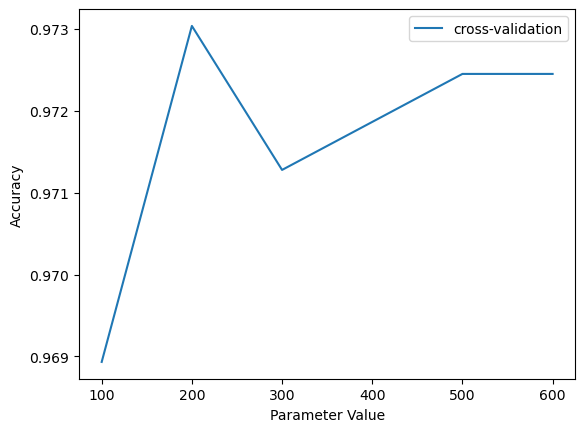

In [ ]:
# This will be the range for my visualization before gridsearching

num_trees = range(100,700,100)

# Here is the plot: x - Tree numbers; y - Accuracy

Accuracy_cv_depth = []
for n in num_trees:
    algorithm = rf = RandomForestClassifier(random_state = 25, n_estimators =int(n))
    predictions_cv = cross_val_predict(algorithm, X_train, y_train, cv=8)
    accuracy_cv = accuracy_score(y_train, predictions_cv,normalize=True, sample_weight=None)
    Accuracy_cv_depth.append(accuracy_cv)
    print("It's normally processing")
results = pd.DataFrame({"num_trees": num_trees, "cross-validation":Accuracy_cv_depth})
tuning_ploter(results)

# As shown, the optimized tree number should be around 100 and more. It may also perform well with 500-600 trees but with the risk of overfitting
# We can use this result n_estimator between [100-200] to save time in grid searching.

It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing


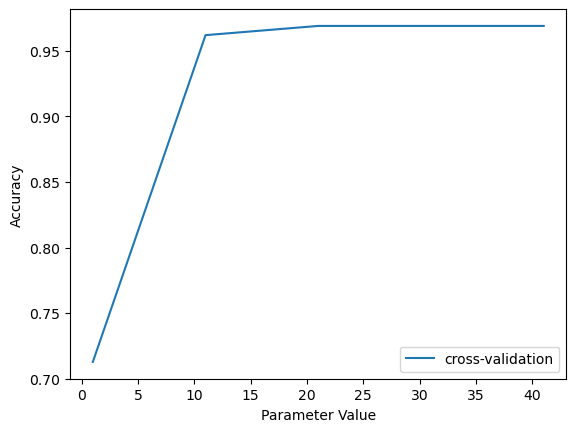

In [ ]:
# This will be the range for my visualization before gridsearching

depth = range(1,50,10)

# Here is the plot: x - Max Depth; y - Accuracy

Accuracy_cv_depth = []
for n in depth:
    algorithm = rf = RandomForestClassifier(random_state = 25, max_depth =int(n))
    predictions_cv = cross_val_predict(algorithm, X_train, y_train, cv=8)
    accuracy_cv = accuracy_score(y_train, predictions_cv,normalize=True, sample_weight=None)
    Accuracy_cv_depth.append(accuracy_cv)
    print("It's normally processing")
results = pd.DataFrame({"num_trees": depth, "cross-validation":Accuracy_cv_depth})
tuning_ploter(results)

# As shown, the optimized maximum depth should be around 10 to prevent overfitting
# We can use this result and save for grid searching on depth in each tree

It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing
It's normally processing


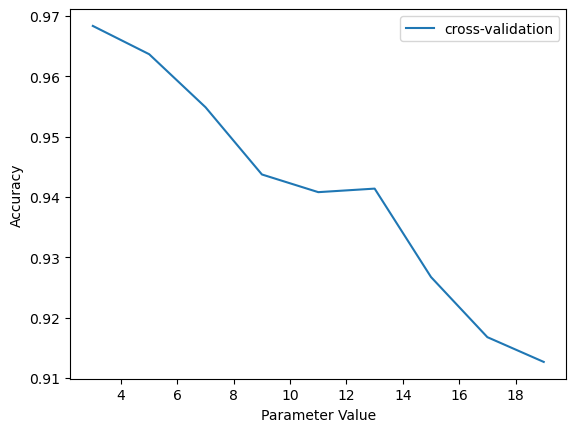

In [ ]:
# This will be the range for my visualization before gridsearching

samples_split = range(3,20,2)

# Here is the plot: x - Minimunn Sample Split; y - Accuracy

Accuracy_cv_depth = []
for n in samples_split:
    algorithm = rf = RandomForestClassifier(random_state = 25, min_samples_split =int(n))
    predictions_cv = cross_val_predict(algorithm, X_train, y_train, cv=8)
    accuracy_cv = accuracy_score(y_train, predictions_cv,normalize=True, sample_weight=None)
    Accuracy_cv_depth.append(accuracy_cv)
    print("It's normally processing")
results = pd.DataFrame({"num_trees": samples_split, "cross-validation":Accuracy_cv_depth})
tuning_ploter(results)

# As shown, the optimized minimunn sample split should be around 3 or un-bounded
# We can use this result and save for grid searching on minimum samples in each tree

It's normally processing
It's normally processing


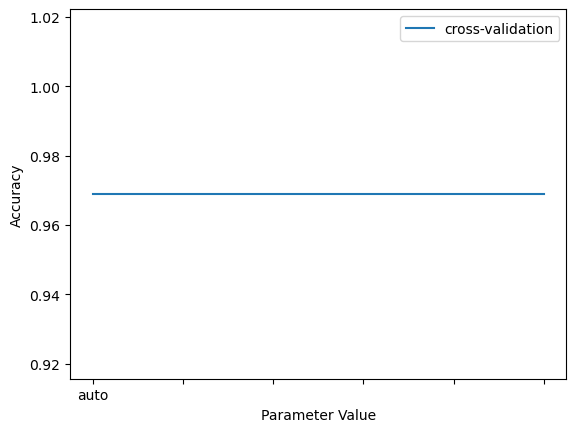

In [ ]:
# This will be the range for my visualization before gridsearching

max_features = ['auto', 'sqrt']
# Here is the plot: x - Max_feature types; y - Accuracy

Accuracy_cv_depth = []
for n in max_features:
    algorithm = rf = RandomForestClassifier(random_state = 25, max_features = n)
    predictions_cv = cross_val_predict(algorithm, X_train, y_train, cv=8)
    accuracy_cv = accuracy_score(y_train, predictions_cv,normalize=True, sample_weight=None)
    Accuracy_cv_depth.append(accuracy_cv)
    print("It's normally processing")
results = pd.DataFrame({"num_trees": max_features, "cross-validation":Accuracy_cv_depth})
tuning_ploter(results)

# As shown, the feature determination type makes no difference on the result.
# We can leave it as default

### **Tuning - Grid Search**

Here we used a smaller range that's calcuated from the graphics above to do the grid search

In [ ]:
# Given the optimal hyper-parameters shown in the plots above. We only do grid search on n_estimator

param_grid = {'n_estimators': range(100,200,20),
    'max_depth': [15],
    'min_samples_split': [2]}

# Create the Grid Search cross-validator
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, n_jobs=-1, verbose=2)

# Train the classifier with the best hyperparameters found by Grid Search
grid_search.fit(X_train, y_train)

# Get the best hyperparameters found by Grid Search
best_params = grid_search.best_params_
print("Best hyperparameters found by Grid Search:")
print(best_params)

# Get the best random forest classifier
best_rf = grid_search.best_estimator_

# Get the cross-validated mean accuracy score on the training set
scores = cross_val_score(best_rf, X_train, y_train, cv=10)
print("Cross-validated mean accuracy score on training set:", scores.mean())

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Best hyperparameters found by Grid Search:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validated mean accuracy score on training set: 0.968923288613691


### **Tuning - ROC & AUC**

In this step we calculate the ROC and AUC to...
1. Check the overall performance of our Random Forest model
2. To tune the model with an optimized threshold

In [ ]:
#create a new random forest classifier
rf = RandomForestClassifier(n_estimators = 180, max_depth = 10, min_samples_split = 2)

# Train the classifier on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=180)

In [ ]:
rf_pred = rf.predict(X_test)

print("Cross-validated accuracy score:", accuracy_score(y_test, rf_pred, normalize = True, sample_weight = None))
precision = precision_score(y_test, rf_pred, average=None)
recall = recall_score(y_test, rf_pred, average=None)
print("Precision:",precision ,"Recall:",recall)

Cross-validated accuracy score: 0.8571428571428571
Precision: [0.88564477 0.46666667] Recall: [0.95789474 0.2295082 ]


In [ ]:
# Get the predicted probabilities for the test data
y_proba_rf = rf.predict_proba(X_test)

# Prepare arrays of false positive, true positive rates, and thresholds to draw ROC curve and to have AUC
fpr, tpr, thresholds_rf = roc_curve(y_test, y_proba_rf[:,1], pos_label=1)

# Here we generate the AUC for the Naive Bayes Model
rf_auc=auc(fpr,tpr)

# Again, even with changing threshold, the generate performance of Naive Bayes Model is unpromising.
print(f"The Area under curve for our Naive Bayes Model is {rf_auc}")

The Area under curve for our Naive Bayes Model is 0.678127696289905


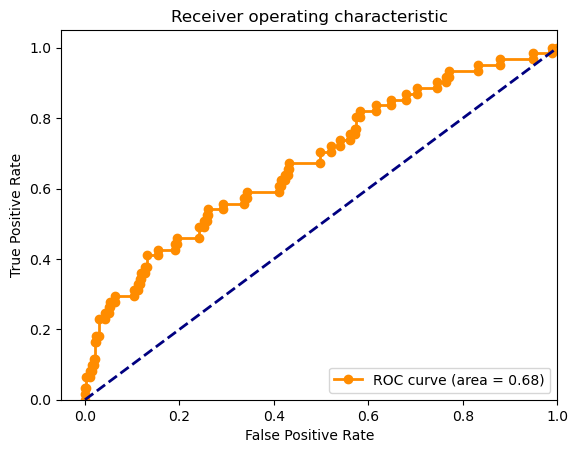

In [ ]:
# Plot the ROC and calculate the AUC for testing dataset.
plt.figure()
lw = 2
plt.plot(fpr, tpr, marker='o',color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % rf_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# We can see from the ROC curve that even with changing threshold, the general performance of Naive Bayes Model is unpromising.
plt.show()

### **Tuning - G-Mean Threshold**

In [ ]:
# Here we calculate the optimal threshold to be used in our test set model by GMean

# Plot the ROC curve
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds_rf})
df_fpr_tpr.head()

# Calculate the G-mean
gmean = np.sqrt(tpr * (1 - fpr))

# Find the optimal threshold
index = np.argmax(gmean)
thresholdOpt_rf = round(thresholds_rf[index], ndigits = 4)
gmeanOpt = round(gmean[index], ndigits = 4)
print('Best Threshold: {} with G-Mean: {}'.format(thresholdOpt_rf, gmeanOpt))

Best Threshold: 0.3305 with G-Mean: 0.6325


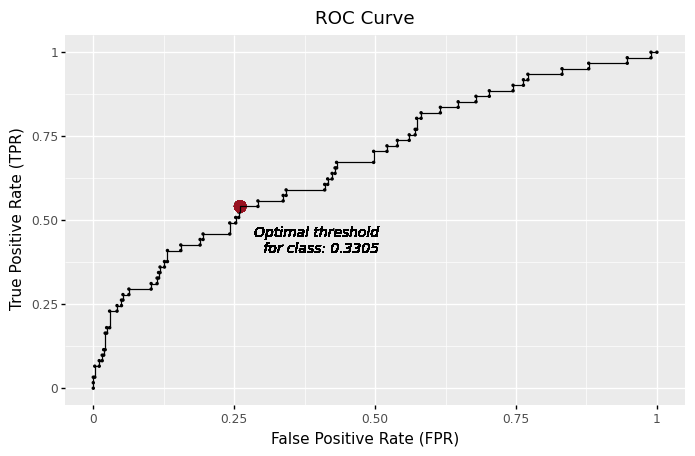

<ggplot: (7916618211641)>

In [ ]:
# (Affiliated) Plot the optimal Threshold's position (Concave point) to be used in our report

fprOpt = round(fpr[index], ndigits = 4)
tprOpt = round(tpr[index], ndigits = 4)

# Create data viz
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    # Best threshold
    geom_point(aes(x = fprOpt,
                   y = tprOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    geom_text(aes(x = fprOpt,
                  y = tprOpt),
              label = 'Optimal threshold \n for class: {}'.format(thresholdOpt_rf),
              nudge_x = 0.14,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate (FPR)')+
    ylab('True Positive Rate (TPR)'))

# **Model Training - Gaussian Naive Bayes Model**

## **Modeling**

In [ ]:
# Create a Gaussian Naive Bayes classifier
nb_model = GaussianNB()

# Train the classifier on the training data
nb_model.fit(X_train, y_train)

# Get the predicted probabilities for the test data
y_proba_gnb = nb_model.predict_proba(X_test)

## **Tuning - ROC & AUC**

In [ ]:
# Prepare arrays of false positive, true positive rates, and thresholds to draw ROC curve and to have AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_gnb[:,1], pos_label=1)

# Here we generate the AUC for the Naive Bayes Model
gnb_auc=auc(fpr,tpr)

# Again, even with changing threshold, the generate performance of Naive Bayes Model is unpromising.
print(f"The Area under curve for our Naive Bayes Model is {gnb_auc}")

The Area under curve for our Naive Bayes Model is 0.6763157894736843


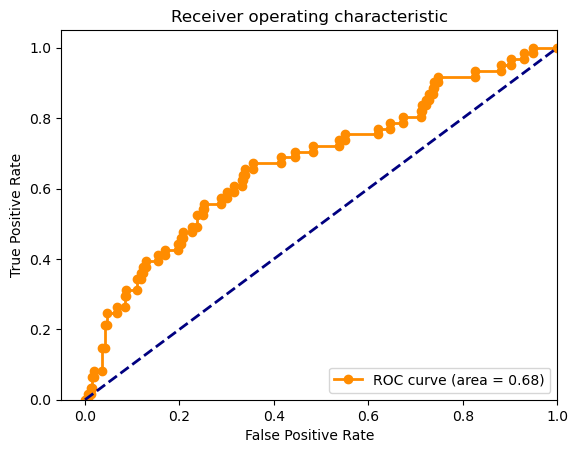

In [ ]:
# Plot the ROC and calculate the AUC for testing dataset.
plt.figure()
lw = 2
plt.plot(fpr, tpr, marker='o',color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % gnb_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# We can see from the ROC curve that even with changing threshold, the general performance of Naive Bayes Model is unpromising.
plt.show()

## **Tuning - G-Mean Threshold**

In [ ]:
# Here we calculate the optimal threshold to be used in our test set model by GMean

# Plot the ROC curve
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds})
df_fpr_tpr.head()

# Calculate the G-mean
gmean = np.sqrt(tpr * (1 - fpr))

# Find the optimal threshold
index = np.argmax(gmean)
thresholdOpt_gnb = round(thresholds[index], ndigits = 4)
gmeanOpt = round(gmean[index], ndigits = 4)
print('Best Threshold: {} with G-Mean: {}'.format(thresholdOpt_gnb, gmeanOpt))

Best Threshold: 0.4073 with G-Mean: 0.6583


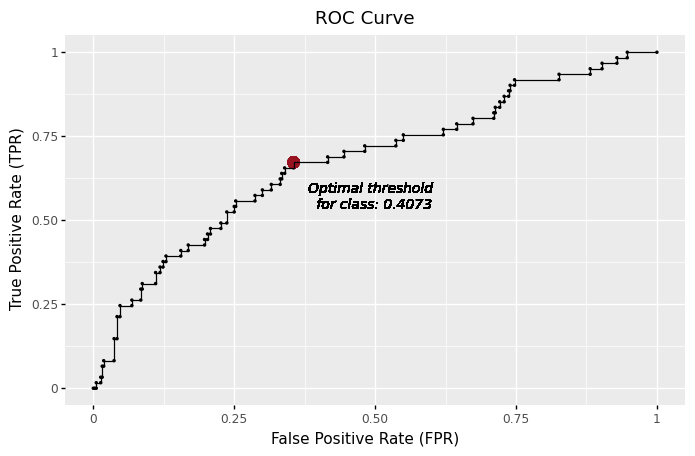

<ggplot: (7916618418585)>

In [ ]:
# (Affiliated) Plot the optimal Threshold's position (Concave point) to be used in our report

fprOpt = round(fpr[index], ndigits = 4)
tprOpt = round(tpr[index], ndigits = 4)

# Create data viz
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    # Best threshold
    geom_point(aes(x = fprOpt,
                   y = tprOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    geom_text(aes(x = fprOpt,
                  y = tprOpt),
              label = 'Optimal threshold \n for class: {}'.format(thresholdOpt_gnb),
              nudge_x = 0.14,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate (FPR)')+
    ylab('True Positive Rate (TPR)'))

# **Model Training - Bernoulli Naive Bayes Model**

## **Modeling**

In [ ]:
# Since our dataset have multiple binary features. The Bernoulli classifier may generate better result.
# Here we repeat the code to compare the Gaussian NB classifiers' performance with Bernoulli NB classifier.
nb_model = BernoulliNB()

In [ ]:
# Train the classifier on the training data
nb_model.fit(X_train, y_train)

# Get the predicted probabilities for the test data
y_proba_bnb = nb_model.predict_proba(X_test)

## **Tuning - ROC & AUC**

In [ ]:
# Prepare arrays of false positive, true positive rates, and thresholds to draw ROC curve and to have AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_bnb[:,1], pos_label=1)

# Here we generate the AUC for the Naive Bayes Model
gnb_auc=auc(fpr,tpr)

# Again, even with changing threshold, the generate performance of Naive Bayes Model is unpromising.
print(f"The Area under curve for our Naive Bayes Model is {gnb_auc}")

The Area under curve for our Naive Bayes Model is 0.6593399482312338


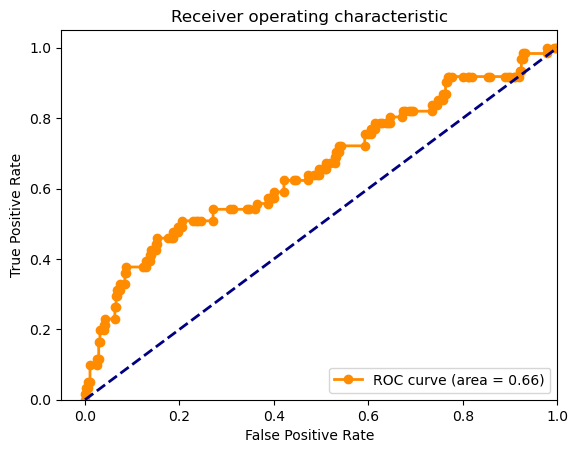

In [ ]:
# Plot the ROC and calculate the AUC for testing dataset.
plt.figure()
lw = 2
plt.plot(fpr, tpr, marker='o',color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % gnb_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# We can see from the ROC curve that even with changing threshold, the general performance of Naive Bayes Model is unpromising.
plt.show()

## **Tuning - G-Mean Threshold**

In [ ]:
# Here we calculate the optimal threshold to be used in our test set model by GMean

# Plot the ROC curve
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds})
df_fpr_tpr.head()

# Calculate the G-mean
gmean = np.sqrt(tpr * (1 - fpr))

# Find the optimal threshold
index = np.argmax(gmean)
thresholdOpt_bnb = round(thresholds[index], ndigits = 4)
gmeanOpt = round(gmean[index], ndigits = 4)
print('Best Threshold: {} with G-Mean: {}'.format(thresholdOpt_bnb, gmeanOpt))

Best Threshold: 0.5842 with G-Mean: 0.6355


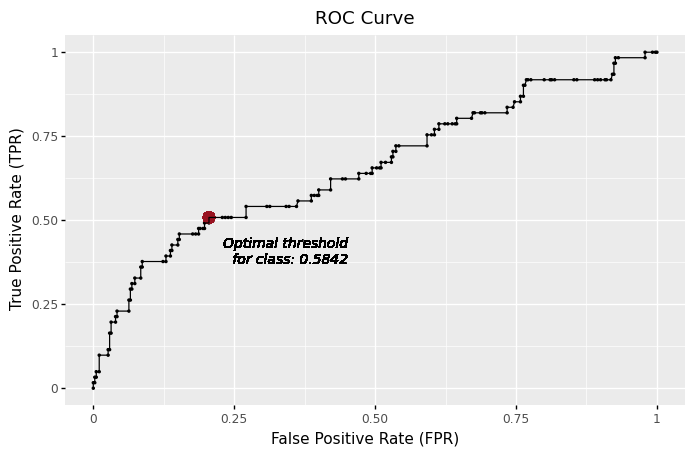

<ggplot: (7916617648701)>

In [ ]:
# (Affiliated) Plot the optimal Threshold's position (Concave point) to be used in our report

fprOpt = round(fpr[index], ndigits = 4)
tprOpt = round(tpr[index], ndigits = 4)

# Create data viz
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    # Best threshold
    geom_point(aes(x = fprOpt,
                   y = tprOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    geom_text(aes(x = fprOpt,
                  y = tprOpt),
              label = 'Optimal threshold \n for class: {}'.format(thresholdOpt_bnb),
              nudge_x = 0.14,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate (FPR)')+
    ylab('True Positive Rate (TPR)'))

# **Model Training - Logistic Regression Model**

In [ ]:
#Built logistic model with L2 regularization and 'saga' as solver
#Use 'L2' as all the features selected are potentially relevant
#Use 'saga' as its faster for large dataset
logistic_model = LogisticRegression(penalty='l2', C=1.0, random_state=0, solver='saga')

# **Model Training - K-Nearest Neighbors Model**

In [ ]:
scoring = "f1"
knn_param_grid = {
    'n_neighbors': list(range(1, 51)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_param_grid, scoring=scoring, cv=5, n_jobs=-1)
knn_grid_search.fit(X_train, y_train.values.ravel())

print("KNN Best Parameters:", knn_grid_search.best_params_)
print("KNN Best Score:", knn_grid_search.best_score_)

best_knn = KNeighborsClassifier(**knn_grid_search.best_params_)
best_knn.fit(X_train, y_train.values.ravel())

KNN Best Parameters: {'metric': 'chebyshev', 'n_neighbors': 1, 'weights': 'uniform'}
KNN Best Score: 0.9326946917505673


KNeighborsClassifier(metric='chebyshev', n_neighbors=1)

# **Model Training - Boosting Algorithm**

In [ ]:
# Create a decision tree classifier with max_depth=1 as the base estimator
base_clf = DecisionTreeClassifier(max_depth=1)

# Create an AdaBoost classifier with n_estimators=50 and learning_rate=1.0
ada_clf = AdaBoostClassifier(base_estimator=base_clf, n_estimators=50, learning_rate=1.0, random_state=42)

# Train the AdaBoost classifier on the training data
ada_clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = ada_clf.predict(X_test)

# Evaluate the performance of the model
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.7301587301587301


## **Hyperparameters tuning-GridSearchCV**

In [ ]:
# Create an AdaBoost classifier with decision stumps as base estimators
ab = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1))

# Define the hyperparameters to search over
param_grid2 = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [1.0, 1.5, 2.0],
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(ab, param_grid=param_grid2, cv=10)
grid_search.fit(X_train, y_train)

# Retrieve the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Train the model with the best hyperparameters
ab_best = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=1), **best_params)
ab_best.fit(X_train, y_train)

# Evaluate the performance of the model
score = ab_best.score(X_test, y_test)
print("Accuracy:", score)

Best hyperparameters: {'learning_rate': 1.5, 'n_estimators': 400}
Accuracy: 0.782312925170068


## **Try Gradient Boost Classifier instead of AdaBoost**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split


# Create a Gradient Boosting classifier
gb = GradientBoostingClassifier()

# Define the hyperparameters to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'max_depth': [3, 5, 7],
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(gb, param_grid=param_grid, cv=10)
grid_search.fit(X_train, y_train)

# Retrieve the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Train the model with the best hyperparameters
gb_best = GradientBoostingClassifier(**best_params)
gb_best.fit(X_train, y_train)

# Evaluate the performance of the model
score = gb_best.score(X_test, y_test)
print("Accuracy:", score)

Best hyperparameters: {'learning_rate': 0.5, 'max_depth': 7, 'n_estimators': 200}
Accuracy: 0.8571428571428571


## **Hyperparametre tuning - Random Resaerch**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint as sp_randint
from scipy.stats import uniform

# Create a Gradient Boosting classifier with decision stumps as weak learners
gb = GradientBoostingClassifier(max_depth=1)

# Define the hyperparameters and their distributions to search over
param_dist = {
    'learning_rate': uniform(loc=0.01, scale=0.99),
    'n_estimators': sp_randint(50, 200),
    'max_depth': sp_randint(1, 20),
}

# Perform random search with cross-validation
random_search = RandomizedSearchCV(gb, param_distributions=param_dist, n_iter=50, cv=10)
random_search.fit(X_train, y_train)

# Retrieve the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters:", best_params)

# Train the model with the best hyperparameters
gb_best = GradientBoostingClassifier(**best_params)
gb_best.fit(X_train, y_train)

# Evaluate the performance of the model
score = gb_best.score(X_test, y_test)
print("Accuracy:", score)

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 

[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=120; total time=   0.5s
[CV] END max_depth=15, min_samples_split=2, n_estimators=120; total time=   0.5s
[CV] END max_depth=15, min_samples_split=2, n_estimators=120; total time=   0.5s
[CV] END max_depth=15, min_samples_split=2, n_estimators=140; total time=   0.6s
[CV] END max_depth=15, min_samples_split=2, n_estimators=140; total time=   0.6s
[CV] END max_depth=15, min_samples_split=2, n_estimators=160; total time=   0.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=160; total time=   0.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=160; total time=   0.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=180; total time=   0.9s
[CV] END max_depth=15, min_samples_split=2, n_estimators=180; total time=   0.9s
[CV] END max_depth=15, min_s

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 

Best hyperparameters: {'learning_rate': 0.6171473366973064, 'max_depth': 8, 'n_estimators': 99}
Accuracy: 0.8639455782312925


# **Evaluation of Models**

## **Evaluation of Random Forest Model**

In [ ]:
# Set the thresholds
threshold_2 = thresholdOpt_rf

# Convert the predicted probabilities to binary predictions using the new thresholds
y_pred_2 = np.where(y_proba_rf[:, 1] >= threshold_2, 1, 0)

# Compute the accuracy score using the new predictions
score_2 = accuracy_score(y_test, y_pred_2)

# Compute the precision and recall scores using the new predictions
precision_2 = precision_score(y_test, y_pred_2, average=None)
recall_2 = recall_score(y_test, y_pred_2, average=None)

# Print the results
print(f"The Optimal (ROC Gmean) Random Forest Model's accuracy score is: {score_2}")
print(f"The Optimal (ROC Gmean) Random Forest Model's precision scores are: {precision_2[0]}")
print(f"The Optimal (ROC Gmean) Random Forest Model's recall scores are: {recall_2[0]}")

The Optimal (ROC Gmean) Random Forest Model's accuracy score is: 0.7097505668934241
The Optimal (ROC Gmean) Random Forest Model's precision scores are: 0.9064516129032258
The Optimal (ROC Gmean) Random Forest Model's recall scores are: 0.7394736842105263


## **Evaluation of Gaussian Naive Bayes Model**

In [ ]:
# Have a review for the performance of Naive Bayes Model for the training data under default threshold of 0.5
score = cross_val_score(nb_model,X_train,y_train,cv=10).mean()

# We can see the result is not very promising.
print(f"The accuracy under Naive Bayes Model, thershold = 0.5, is {score}")

The accuracy under Naive Bayes Model, thershold = 0.5, is 0.710374957000344


### **Affiliated - Reasoning on high accuracy: Does it matter?**

In [ ]:
# Set the thresholds
threshold_1 = 1
threshold_2 = thresholdOpt_gnb

# Convert the predicted probabilities to binary predictions using the new thresholds
y_pred_1 = np.where(y_proba_gnb[:, 1] >= threshold_1, 1, 0)
y_pred_2 = np.where(y_proba_gnb[:, 1] >= threshold_2, 1, 0)

# Compute the accuracy score using the new predictions
score_1 = accuracy_score(y_test, y_pred_1)
score_2 = accuracy_score(y_test, y_pred_2)

# Compute the precision and recall scores using the new predictions
precision_1 = precision_score(y_test, y_pred_1, average=None)
recall_1 = recall_score(y_test, y_pred_1, average=None)
precision_2 = precision_score(y_test, y_pred_2, average=None)
recall_2 = recall_score(y_test, y_pred_2, average=None)

# Print the results.

# We displayed the "optimal accuracy" threshold to show that it is not that we can't let it ganerate an as high as 86% accuracy.
# But by just changing the threhold high, it simply making the model another majority class classifier.
# Instead, we want to focus on the recall and precision's performance using the optimal G-Mean threshold.

print(f"The Optimal (Accuracy) Native Bayes Model's accuracy score is: {score_1}")
print(f"The Optimal (Accuracy) Native Bayes Model's precision scores are: {precision_1[0]}")
print(f"The Optimal (Accuracy) Native Bayes Model's recall scores are: {recall_1[0]}\n")

print(f"The Optimal (Gmean) Gaussian Native Bayes Model's accuracy score is: {score_2}")
print(f"The Optimal (Gmean) Gaussian Native Bayes Model's precision score is: {precision_2[0]}")
print(f"The Optimal (Gmean) Gaussian Native Bayes Model's recall score is: {recall_2[0]}")

The Optimal (Accuracy) Native Bayes Model's accuracy score is: 0.8616780045351474
The Optimal (Accuracy) Native Bayes Model's precision scores are: 0.8616780045351474
The Optimal (Accuracy) Native Bayes Model's recall scores are: 1.0

The Optimal (Gmean) Gaussian Native Bayes Model's accuracy score is: 0.6485260770975056
The Optimal (Gmean) Gaussian Native Bayes Model's precision score is: 0.9245283018867925
The Optimal (Gmean) Gaussian Native Bayes Model's recall score is: 0.6447368421052632


## **Evaluation of Bernoulli Naive Bayes Model**

In [ ]:
# Set the thresholds
threshold_2 = thresholdOpt_bnb

# Convert the predicted probabilities to binary predictions using the new thresholds
y_pred_2 = np.where(y_proba_bnb[:, 1] >= threshold_2, 1, 0)

# Compute the accuracy score using the new predictions
score_2 = accuracy_score(y_test, y_pred_2)

# Compute the precision and recall scores using the new predictions
precision_2 = precision_score(y_test, y_pred_2, average=None)
recall_2 = recall_score(y_test, y_pred_2, average=None)


# The general performance of our optimal threshold Bernoulli Native Bayes Model is better than Gaussian.
# A more detailed evaluation between the two classifier's result can be found in the report.
print(f"The Optimal (ROC Gmean) Bernoulli Native Bayes Model's accuracy score is: {score_2}")
print(f"The Optimal (ROC Gmean) Bernoulli Native Bayes Model's precision score is: {precision_2[0]}")
print(f"The Optimal (ROC Gmean) Bernoulli Native Bayes Model's recall score is: {recall_2[0]}")

The Optimal (ROC Gmean) Bernoulli Native Bayes Model's accuracy score is: 0.7528344671201814
The Optimal (ROC Gmean) Bernoulli Native Bayes Model's precision score is: 0.9069069069069069
The Optimal (ROC Gmean) Bernoulli Native Bayes Model's recall score is: 0.7947368421052632


## **Evaluation of Logistic Regression Model**

In [ ]:
# cross validation prediction on training set
y_array_train = y_train.values.ravel()
logistic_preds = cross_val_predict(logistic_model, X_train, y_array_train, cv=10)
print (f'This is prediction for logistic regression: \n {logistic_preds}\n')
print('Cross validation accuracy on training set:')
print(accuracy_score(y_array_train, logistic_preds, normalize=True, sample_weight=None))
print(f'This is confusion matrix for logistic regression: \n{confusion_matrix(y_array_train, logistic_preds)}\n')

This is prediction for logistic regression: 
 [0 0 0 ... 1 1 1]

Cross validation accuracy on training set:
0.7479484173505275
This is confusion matrix for logistic regression: 
[[649 204]
 [226 627]]



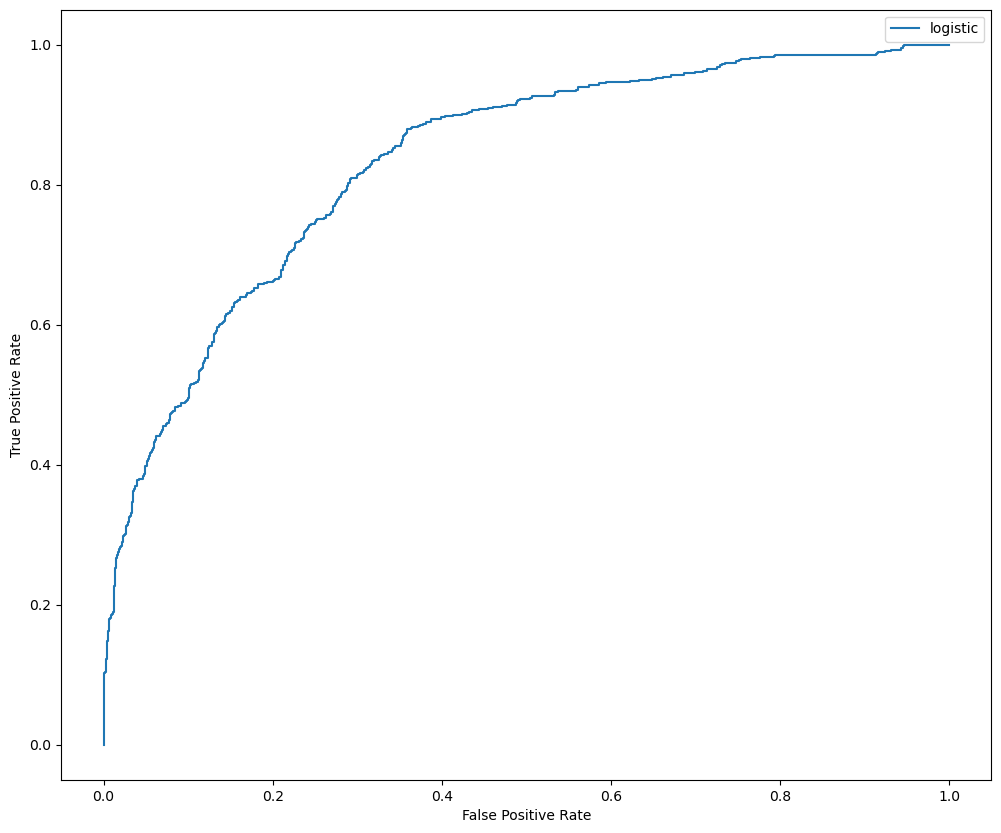

In [ ]:
# Choose 'predict_proba' (which gives probabilities) for the method parameter.
logistic_preds_prob = cross_val_predict(logistic_model, X_train, y_array_train, cv=10, method="predict_proba")
logistic_preds_prob_1 = cross_val_predict(logistic_model, X_train, y_array_train, cv=10, method="predict_proba")[:,1]

# Get false positive and true positives for each model
logistic_fpr, logistic_tpr, thresholds = roc_curve(y_train, logistic_preds_prob_1)

# Plot the ROC curves
plt.figure(figsize=(12, 10))
plt.plot(logistic_fpr, logistic_tpr, label="logistic")
plt.legend()
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

In [ ]:
from sklearn.metrics import auc
# Get AUC
logistic_auc = auc(logistic_fpr, logistic_tpr)
pd.DataFrame({"Model":['Logistic Regression'], "AUC":[logistic_auc]})

,Model,AUC
0,Logistic Regression,0.832861


In [ ]:
from sklearn.model_selection import GridSearchCV
# Search for best complexity when optimizing for AUC for logistic regression
l_grid = {"C": [10**i for i in np.arange(-1, 2, 0.1)]}
l_searcher = GridSearchCV(logistic_model, l_grid, cv=10, scoring="roc_auc")
l_searcher.fit(X_train, y_array_train)

# Plot result
print(f"Best C for logsitic regression: {l_searcher.best_params_}")
print(f"Best AUC: {l_searcher.best_score_}")

Best C for logsitic regression: {'C': 9.99999999999999}
Best AUC: 0.833512030256699


In [ ]:
#Create best performed logistic regression model with C=31.62277660168376
logistic_model_final = LogisticRegression(penalty='l2', C=31.62277660168376, solver='saga')
logistic_model_final.fit(X_train,y_array_train)
print('Coefficient of each features in finalized logistic regression model: ', logistic_model_final.coef_)

Coefficient of each features in finalized logistic regression model:  [[ 0.7037024  -0.01340327  0.02948559 -0.07091096 -0.14522247  0.0656675
   0.11950041 -0.01644052 -0.11696399 -0.18786866 -0.02332342 -0.14789001
  -0.02542144  0.31043223  1.45839491  1.06186994 -0.34113399  0.31168385
  -0.34420403  0.05081021 -0.19434386 -0.16252937  0.53895022  0.11972201
   0.84977275 -0.21972061  0.25494797 -0.14246337  0.69944075]]


In [ ]:
#Prediction of finalized model on testing set
logistic_prediction = logistic_model_final.predict(X_test)
logistic_prediction

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,

In [ ]:
#Confusion matrix for logistic regression
print(f'This is confusion matrix for logistic regression: \n{confusion_matrix(y_test, logistic_prediction)}\n')


This is confusion matrix for logistic regression: 
[[272 108]
 [ 25  36]]



In [ ]:
#Statistic of logistic regression model performance
print(f'Accuracy of logistic regression model: {accuracy_score(y_test, logistic_model_final.predict(X_test), normalize=True, sample_weight=None)}')
print(f'Precision of logistic regression model: {precision_score(y_test, logistic_model_final.predict(X_test), pos_label = 0, sample_weight=None)}')
print(f'Recall of logistic regression model: {recall_score(y_test, logistic_model_final.predict(X_test), pos_label = 0, sample_weight=None)}')
print('Classification overeall report:')
print(classification_report(y_test, logistic_model_final.predict(X_test), sample_weight=None))

Accuracy of logistic regression model: 0.6984126984126984
Precision of logistic regression model: 0.9158249158249159
Recall of logistic regression model: 0.7157894736842105
Classification overeall report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.80       380
           1       0.25      0.59      0.35        61

    accuracy                           0.70       441
   macro avg       0.58      0.65      0.58       441
weighted avg       0.82      0.70      0.74       441



## **Evaluation of K-Nearest Neighbors Model**

In [ ]:
knn_predictions = best_knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)
print("KNN F1 Score:", knn_f1)


KNN Accuracy: 0.780045351473923
KNN Precision: 0.07142857142857142
KNN Recall: 0.04918032786885246
KNN F1 Score: 0.058252427184466014


## **Evaluation of Boosting Algorithm**

In [ ]:
from sklearn.metrics import classification_report

# Assume you have trained and evaluated a GradientBoostingClassifier
# and stored the predictions in y_pred and the ground truth labels in y_true
y_pred1 = gb_best.predict(X_test)
y_true1 = y_test

# Compute the classification report
report = classification_report(y_true1, y_pred1)

# Print the report
print(report)

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       380
           1       0.53      0.15      0.23        61

    accuracy                           0.86       441
   macro avg       0.70      0.56      0.58       441
weighted avg       0.83      0.86      0.83       441

